In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-colorblind")
%matplotlib inline

SNOWGLOBES_ROOT = Path("..").resolve()     # if notebook lives in snowglobes/plots/
FLUX_DIR = SNOWGLOBES_ROOT / "fluxes"

In [2]:
def load_flux_table(path: Path):
    data = np.loadtxt(path, comments="#")
    if data.ndim == 1:
        data = data[None, :]
    if data.shape[1] < 2:
        raise ValueError(f"{path} has <2 columns; cannot plot.")
    E = data[:, 0]
    Y = data[:, 1:]
    return E, Y

In [31]:
DEFAULT_LABELS_6FLAV = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$", r"$\bar{\nu}_e$", r"$\bar{\nu}_\mu$", r"$\bar{\nu}_\tau$"]

def plot_flux(path: Path, labels=None, logy=True, title=None):
    E, Y = load_flux_table(path)
    if labels is None:
        labels = DEFAULT_LABELS_6FLAV if Y.shape[1] == 6 else [f"col{i+2}" for i in range(Y.shape[1])]

    fig, ax = plt.subplots(figsize=(7, 5))
    
    ax.plot(E, Y)

    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel("Flux (file units)")
    if logy:
        ax.set_yscale("log")
    ax.grid(True, which="both", ls=":")
    ax.legend()
    ax.set_title(title or path.name)
    ax.set_xlim(0, 0.06)


    return fig, ax

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


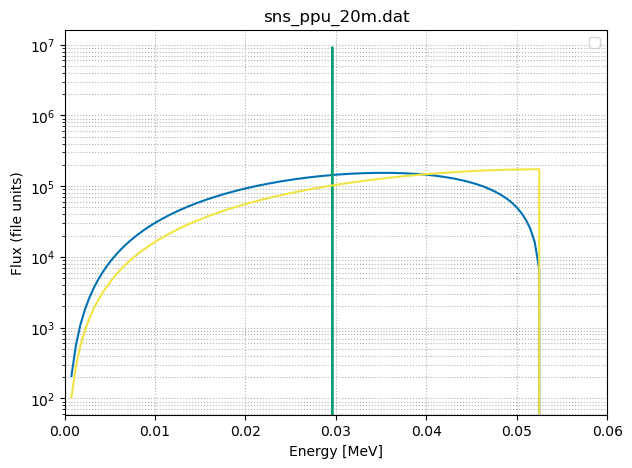

In [32]:
# flux_file = FLUX_DIR / "solar_bs05op_mixed.dat"
# flux_file = FLUX_DIR / "gvkm.dat"
flux_file = FLUX_DIR / "sns_ppu_20m.dat"
# flux_file = FLUX_DIR / "livermore.dat"

fig, ax = plot_flux(flux_file, logy=-True)